In [ ]:
!pip install gower==0.0.5
!pip install python-dateutil

import numpy as np
import pandas as pd
import time
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler
from google.colab import files
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Load data
DATA_PATH = "/content/CDC Diabetes Dataset.csv"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())

Shape: (253680, 21)


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,1,1,1,40,1,0,0,0,0,1,...,1,0,5,18,15,1,0,9,4,3
1,0,0,0,25,1,0,0,1,0,0,...,0,1,3,0,0,0,0,7,6,1
2,1,1,1,28,0,0,0,0,1,0,...,1,1,5,30,30,1,0,9,4,8
3,1,0,1,27,0,0,0,1,1,1,...,1,0,2,0,0,0,0,11,3,6
4,1,1,1,24,0,0,0,1,1,1,...,1,0,2,3,0,0,0,11,5,4


In [ ]:
# Tentukan kolom numerik, ordinal dan kategorikal
all_cols = df.columns.tolist()
# Asumsi: ada kolom label "Diabetes_binary" atau "Diabetes_012", hapus label dari fitur
label_cols = [c for c in all_cols if "Diabetes" in c or c.lower().startswith("diabetes")]
features = [c for c in all_cols if c not in label_cols]

# Bagi data
numeric_cols = ["BMI"]
ordinal_cols = ["GenHlth", "MentHlth", "PhysHlth", "Age", "Education", "Income"]
cat_cols = [c for c in features if c not in numeric_cols + ordinal_cols]

print("Numerik :", numeric_cols)
print("Ordinal :", ordinal_cols)
print("Kategorik :", cat_cols)

Numerik : ['BMI']
Ordinal : ['GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']
Kategorik : ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']


In [ ]:
# Preprocessing
for c in cat_cols:
    if c in df.columns:
        df[c] = df[c].astype(int)
        df[c] = df[c].fillna(df[c].median())
        df[c] = df[c].fillna(0).astype(int).astype('category')

for c in ordinal_cols:
    if c in df.columns:
        df[c] = df[c].astype(int)
        df[c] = df[c].fillna(df[c].median())
        df[c] = df[c].fillna(0).astype(int).astype('category')

for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce').astype(float)
        df[c] = df[c].fillna(df[c].median())
print("\n--- Informasi missing value ---")
df.info()

for c in cat_cols:
    if pd.api.types.is_categorical_dtype:
        df[c] = df[c].fillna(0).astype(int)
for c in ordinal_cols:
    if pd.api.types.is_categorical_dtype:
        df[c] = df[c].fillna(1).astype(int)

X_raw = df[features].copy() # Data asli fitur
X = X_raw.copy() # Data untuk clustering
Y = X_raw.copy() # Data untuk deteksi outlier
# Outlier
# Deteksi Jumlah Outlier
def detect_outliers_iqr(df_local, cols):
    det = df_local.copy()
    for col in cols:
        if col in det.columns and pd.api.types.is_numeric_dtype(det[col]):
            Q1 = det[col].quantile(0.25)
            Q3 = det[col].quantile(0.75)
            IQR = Q3 - Q1
            lb = Q1 - 1.5 * IQR # Batas bawah
            ub = Q3 + 1.5 * IQR # Batas Atas
            det = det[(det[col] >= lb) & (det[col] <= ub)]
    return det
# Mengganti outlier dengan batas atas dan batas bawah
def winsorize_iqr(df_local, cols):
    dfc = df_local.copy()
    for col in cols:
        if col in dfc.columns and pd.api.types.is_numeric_dtype(dfc[col]):
            Q1 = dfc[col].quantile(0.25)
            Q3 = dfc[col].quantile(0.75)
            IQR = Q3 - Q1
            lb = Q1 - 1.5 * IQR
            ub = Q3 + 1.5 * IQR
            # Jika nilai datanya < batas bawah, ganti dengan lb
            # Jika nilai datanya > batas atas, ganti dengan ub
            # Jika nilai datanya ada diantara lb dan ub, maka nilai data diubah menjadi nilai batas terdekat
            dfc[col] = np.where(dfc[col] < lb, lb,
                        np.where(dfc[col] > ub, ub, dfc[col]))
    return dfc

# Kolom yang dicek outlier
num_outlier_cols = [c for c in ['BMI','GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income'] if c in X.columns]
if len(num_outlier_cols) > 0:
    X = winsorize_iqr(X, num_outlier_cols) # Perbaiki outlier dengan winsorize
    print("Outliers have been winsorized (capped)")
    before = Y.shape[0]
    Y = detect_outliers_iqr(Y, num_outlier_cols) # Deteksi outlier
    after = Y.shape[0]
    print(f"Terdeteksi {before-after} baris sebagai outlier oleh IQR")

# print("Preprocessed shape:", X.shape)
# X.to_csv("preprocessed_dataset.csv", index=False)
# files.download("preprocessed_dataset.csv")
display(X.head()) # Tampilkan data setelah preprocessing


--- Informasi missing value ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 21 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   HighBP                253680 non-null  category
 1   HighChol              253680 non-null  category
 2   CholCheck             253680 non-null  category
 3   BMI                   253680 non-null  float64 
 4   Smoker                253680 non-null  category
 5   Stroke                253680 non-null  category
 6   HeartDiseaseorAttack  253680 non-null  category
 7   PhysActivity          253680 non-null  category
 8   Fruits                253680 non-null  category
 9   Veggies               253680 non-null  category
 10  HvyAlcoholConsump     253680 non-null  category
 11  AnyHealthcare         253680 non-null  category
 12  NoDocbcCost           253680 non-null  category
 13  GenHlth               253680 non-null  category
 14  Men

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,1,1,1,40.0,1,0,0,0,0,1,...,1,0,4.5,5.0,7.5,1,0,9.0,4.0,3.0
1,0,0,0,25.0,1,0,0,1,0,0,...,0,1,3.0,0.0,0.0,0,0,7.0,6.0,1.0
2,1,1,1,28.0,0,0,0,0,1,0,...,1,1,4.5,5.0,7.5,1,0,9.0,4.0,8.0
3,1,0,1,27.0,0,0,0,1,1,1,...,1,0,2.0,0.0,0.0,0,0,11.0,3.0,6.0
4,1,1,1,24.0,0,0,0,1,1,1,...,1,0,2.0,3.0,0.0,0,0,11.0,5.0,4.0


In [ ]:
# Menghitung R untuk perhitungan jarak Gower
num_max = {c: df[c].max() for c in numeric_cols} # Nilai maksimum dari kolom c
num_min = {c: df[c].min() for c in numeric_cols} # Nilai minimum dari kolom c

ordinal_max = {c: X[c].max() for c in ordinal_cols}
ordinal_min = {c: X[c].min() for c in ordinal_cols}

print("Range siap digunakan.")

Range siap digunakan.


In [ ]:
# Perhiutngan jarak Gower
def gower_dist_to_prototype(df, proto):
    n = len(df) # Jumlah data
    r = len(features) # Jumlah fitur
    dist = np.zeros(n)

    for c in features:
        col = df[c].to_numpy()

        # Numerik
        if c in numeric_cols:
            denom = num_max[c] - num_min[c]
            dp = np.abs(col - float(proto[c])) / (denom if denom != 0 else 1)

        # Ordinal
        elif c in ordinal_cols:
            denom = ordinal_max[c] - ordinal_min[c]
            dp = np.abs(col - float(proto[c])) / (denom if denom != 0 else 1)

        # Kategori
        else:
            dp = (col != proto[c]).astype(float)

        dist += dp # Akumulasi jarak

    return dist / r

In [ ]:
# Fungsi menghitung prototipe cluster
def compute_prototype_from_U(df, U_col, m=2.0):
    w = (U_col ** m) # Bobot fuzzy
    sum_w = w.sum()
    proto = {}
    # numerik
    for c in numeric_cols:
        if sum_w > 0:
            proto[c] = float((w * df[c].to_numpy()).sum() / sum_w)
        else:
            proto[c] = float(df[c].median())
    # ordinal
    for c in ordinal_cols:
        if sum_w > 0:
            proto[c] = float((w * df[c].to_numpy()).sum() / sum_w)
        else:
            proto[c] = float(df[c].median())
    # kategorik
    for c in cat_cols:
        vals = df[c].to_numpy()
        weight_per_cat = {}
        for val,wt in zip(vals, w):
            weight_per_cat[val] = weight_per_cat.get(val, 0.0) + wt
        if weight_per_cat:
            proto[c] = max(weight_per_cat.items(), key=lambda x: x[1])[0]
        else:
            proto[c] = df[c].mode().iloc[0]
    return proto

In [ ]:
# Update matriks U (derajat keanggotaan)
def update_membership_from_dist(D, m=2.0):
    # D: n x k distances (nonnegative)
    # returns U_new: n x k
    power = 2.0 / (m - 1.0)
    n,k = D.shape
    U = np.zeros_like(D, dtype=float)
    # handle zeros: if D[i,j]==0 -> U[i,:] are 0 except j is 1
    for i in range(n):
        di = D[i]
        if np.any(di == 0): # Jika jarak nol
            j0 = np.argmin(di)
            urow = np.zeros(k)
            urow[j0] = 1.0
            U[i] = urow
            continue
        # normal case
        # avoid division by zero by small eps
        denom = np.sum((di[:,None] / di[None,:])**power, axis=1)
        # denom is vector of length k; compute 1/denom
        U[i] = 1.0 / denom
    return U
# Fungsi objektif HPFCM
def objective_J(U, D, m=2.0):
    return np.sum((U ** m) * (D ** 2))

In [ ]:
# Inisialisas U random
def init_U(n, k, random_state=42):
    np.random.seed(random_state)
    U = np.random.rand(n, k)
    U = U / U.sum(axis=1, keepdims=True)
    return U

In [ ]:
# Cell 10 — FCM loop using Gower-distance-to-prototypes
def fcm_gower(df, k=2, m=2.0, max_iter=500, eps_f=1e-5, random_state=42, verbose=True):
    # Menentukan parameter awal
    n = len(df)
    np.random.seed(random_state)
    # Inisialisasi matriks U^(0)
    U = init_U(n, k, random_state=random_state)
    # Untuk menyimpan nilai fungsi tujuan
    J_hist = []
    J_prev = None
    #  Proses iteratif FCM
    for t in range(max_iter):
        # Menentukan pusat cluster v_j
        prototypes = [compute_prototype_from_U(df, U[:, j], m=m) for j in range(k)]
        # Menghitung jarak dan fungsi tujuan J_fcm^t
        D = np.column_stack([gower_dist_to_prototype(df, proto) for proto in prototypes])

        # Hitung fungsi tujuan
        J = objective_J(U, D, m=m)
        J_hist.append(J)
        # Cek kriteria penghentian
        if J_prev is not None:
            delta_J = abs(J - J_prev)
        else:
            delta_J = np.inf

        if verbose:
            print(f"FCM iter {t+1}, J={J:.6f}, ΔJ={delta_J:.6e}")

        if delta_J < eps_f:
            if verbose:
                print(f"Stopping at iteration {t+1} because ΔJ={delta_J:.3e} < eps_f={eps_f}")
            break
        J_prev = J
        # Memperbarui matriks U^(t+1)
        U_new = update_membership_from_dist(D, m=m)
        U = U_new.copy()
    # Hasil akhir
    prototypes = [ compute_prototype_from_U(df, U[:,j], m=m) for j in range(k) ]
    labels = np.argmax(U, axis=1)
    return {"U":U, "prototypes":prototypes, "J_hist":J_hist, "labels":labels}

In [ ]:
import numpy as np
import random
# 1. K-Means++ Initialization (mengikuti langkah skripsi)
def kmeans_pp_init(df, k=2, random_state=42):
    np.random.seed(random_state)
    N = len(df)
    ids = list(range(N))
    # pilih satu titik secara acak
    first = np.random.choice(ids)
    centers = [first]
    # iterasi pemilihan pusat cluster
    for _ in range(1, k):
        # hitung jarak terdekat D(x_i)^2
        dmin = np.full(N, np.inf)
        for cidx in centers:
            proto = {col: df.loc[cidx, col] for col in df.columns}
            d = gower_dist_to_prototype(df, proto)
            dmin = np.minimum(dmin, d)
        # probabilitas P(x_i)
        probs = dmin**2
        if probs.sum() == 0:
            nxt = np.random.choice(ids)
        else:
            probs /= probs.sum()
            nxt = np.random.choice(ids, p=probs)
        centers.append(nxt)
    # matriks V' berisi prototipe awal
    prototypes = [{col: df.loc[idx, col] for col in df.columns} for idx in centers]
    return prototypes

# # 2. O-K-Means Optimization
def okmeans_optimize(df, V_init, eps_ok=1e-4, max_iter=50):
    V = V_init.copy()
    k = len(V)
    n = len(df)
    hard_labels_prev = None   # untuk cek perpindahan cluster

    for t in range(max_iter):

        # Hitung jarak ke seluruh pusat
        D = np.column_stack([gower_dist_to_prototype(df, v) for v in V])
        hard_labels = np.argmin(D, axis=1)

        # ---------- Hitung o_t sesuai skripsi ----------
        if hard_labels_prev is None:
            o_t = 0   # iterasi pertama dianggap semua berubah
        else:
            o_t = np.sum(hard_labels != hard_labels_prev)

        # Rumus gamma_t dari skripsi
        gamma_t = 100 * (o_t / n)

        # Stop sesuai eps_ok
        if gamma_t <= eps_ok:
            break

        hard_labels_prev = hard_labels.copy()

        # ---------- Update pusat cluster ----------
        V_new = []
        for j in range(k):
            idx = np.where(hard_labels == j)[0]
            if len(idx) == 0:
                V_new.append(V[j])
            else:
                proto = {col: np.mean(df.iloc[idx][col]) for col in df.columns}
                V_new.append(proto)

        V = V_new.copy()

    return V

# 3. Transformasi S: V'' → U(0)
def membership_from_centers(df, prototypes, m=2.0):
    D = np.column_stack([gower_dist_to_prototype(df, v) for v in prototypes])
    U = update_membership_from_dist(D, m=m)
    return U, D

# 4. HPFCM Iteration
def hpfcm_gower(df, k=2, m=2.0,
                eps_h=1e-5, eps_ok=1e-4,
                max_iter_fcm=500, verbose=True, random_state=42):
    # STEP 1: K-Means++ → V'
    V_prime = kmeans_pp_init(df, k=k, random_state=random_state)
    # STEP 2: O-K-Means → V''
    V_pp = okmeans_optimize(df, V_prime, eps_ok=eps_ok, max_iter=50)
    # STEP 3: Transformasi S → U(0)
    U, D = membership_from_centers(df, V_pp, m=m)
    # STEP 4: FCM Iteration
    J_hist = []
    J_prev = None

    for it in range(max_iter_fcm):
        # Update prototipe fuzzy
        prototypes = [compute_prototype_from_U(df, U[:, j], m=m) for j in range(k)]

        # Hitung jarak baru
        D = np.column_stack([gower_dist_to_prototype(df, p) for p in prototypes])

        # Update keanggotaan fuzzy
        U_new = update_membership_from_dist(D, m=m)

        # Hitung J_m
        J = objective_J(U_new, D, m=m)
        J_hist.append(J)

        # Hitung ΔJ sesuai skripsi
        if J_prev is not None:
            delta_J = 100 * abs(J_prev - J) / (J_prev)
        else:
            delta_J = np.inf

        if verbose:
            print(f"HPFCM iter {it+1}, J={J:.6f}, ΔJ={delta_J:.6e}")

        # update
        U = U_new.copy()
        J_prev = J

        # stopping criteria
        if delta_J <= eps_h:
            if verbose:
                print(f"Stopping HPFCM at iteration {it+1} (ΔJ={delta_J:.3e})")
            break
    labels = np.argmax(U, axis=1)
    return {"U":U, "prototypes":prototypes, "J_hist":J_hist, "labels":labels}

In [ ]:
# Run FCM (k=2)
k=2
m = 2.0
t0 = time.time()
res_fcm = fcm_gower(df[features], k=k, m=m, max_iter=500, eps_f=1e-5, random_state=42, verbose=True)
t_fcm = time.time() - t0
print("FCM done in", t_fcm, "s. Iterations:", len(res_fcm["J_hist"]))
avg_J_fcm = np.mean(res_fcm["J_hist"])
print("Rata-rata nilai fungsi tujuan J (FCM) untuk k=",k,"adalah: ", avg_J_fcm)

FCM iter 1, J=14611.198236, ΔJ=inf
FCM iter 2, J=11897.258359, ΔJ=2.713940e+03
FCM iter 3, J=11897.258476, ΔJ=1.179076e-04
FCM iter 4, J=11897.258629, ΔJ=1.528070e-04
FCM iter 5, J=11897.258706, ΔJ=7.724559e-05
FCM iter 6, J=11897.258753, ΔJ=4.644403e-05
FCM iter 7, J=11897.258788, ΔJ=3.534297e-05
FCM iter 8, J=11897.258819, ΔJ=3.109029e-05
FCM iter 9, J=11897.258848, ΔJ=2.913999e-05
FCM iter 10, J=11897.258876, ΔJ=2.797245e-05
FCM iter 11, J=11897.258904, ΔJ=2.708196e-05
FCM iter 12, J=11897.258930, ΔJ=2.629883e-05
FCM iter 13, J=11897.258955, ΔJ=2.556539e-05
FCM iter 14, J=11897.258980, ΔJ=2.486168e-05
FCM iter 15, J=11897.259004, ΔJ=2.418052e-05
FCM iter 16, J=11897.259028, ΔJ=2.351913e-05
FCM iter 17, J=11897.259051, ΔJ=2.287622e-05
FCM iter 18, J=11897.259073, ΔJ=2.225100e-05
FCM iter 19, J=11897.259095, ΔJ=2.164293e-05
FCM iter 20, J=11897.259116, ΔJ=2.105149e-05
FCM iter 21, J=11897.259136, ΔJ=2.047621e-05
FCM iter 22, J=11897.259156, ΔJ=1.991666e-05
FCM iter 23, J=11897.259176,

In [ ]:
# Run HPFCM (k=2)
eps_h=1e-5       # threshold HPFCM
eps_ok=1e-4      # threshold O-K-Means
max_iter_fcm = 500
t0_total = time.time()
res_hpfcm = hpfcm_gower(df[features], k=k, m=m, eps_h=eps_h, eps_ok=eps_ok, max_iter_fcm=max_iter_fcm, verbose=True, random_state=42)
t_hpfcm = time.time() - t0_total
print("HPFCM done in", t_hpfcm, "s. Iterations:", len(res_hpfcm["J_hist"]))
# Rata-rata nilai fungsi tujuan J selama iterasi HPFCM
avg_J_hpfcm = np.mean(res_hpfcm["J_hist"])
print("Rata-rata nilai fungsi tujuan J (HPFCM) untuk k=",k,"adalah: ", avg_J_hpfcm)

HPFCM iter 1, J=11285.486821, ΔJ=inf
HPFCM iter 2, J=11133.127734, ΔJ=1.350044e+00
HPFCM iter 3, J=11055.393578, ΔJ=6.982239e-01
HPFCM iter 4, J=11010.534731, ΔJ=4.057644e-01
HPFCM iter 5, J=10985.281806, ΔJ=2.293524e-01
HPFCM iter 6, J=10973.256357, ΔJ=1.094687e-01
HPFCM iter 7, J=10966.523622, ΔJ=6.135585e-02
HPFCM iter 8, J=10963.805175, ΔJ=2.478859e-02
HPFCM iter 9, J=10962.284385, ΔJ=1.387101e-02
HPFCM iter 10, J=10961.352299, ΔJ=8.502656e-03
HPFCM iter 11, J=10960.775349, ΔJ=5.263499e-03
HPFCM iter 12, J=10960.417578, ΔJ=3.264097e-03
HPFCM iter 13, J=10960.195554, ΔJ=2.025695e-03
HPFCM iter 14, J=10960.057705, ΔJ=1.257717e-03
HPFCM iter 15, J=10959.972094, ΔJ=7.811254e-04
HPFCM iter 16, J=10959.918913, ΔJ=4.852240e-04
HPFCM iter 17, J=10959.885874, ΔJ=3.014515e-04
HPFCM iter 18, J=10959.865347, ΔJ=1.872952e-04
HPFCM iter 19, J=10959.852593, ΔJ=1.163743e-04
HPFCM iter 20, J=10959.844668, ΔJ=7.231043e-05
HPFCM iter 21, J=10959.839743, ΔJ=4.493175e-05
HPFCM iter 22, J=10959.836683, 

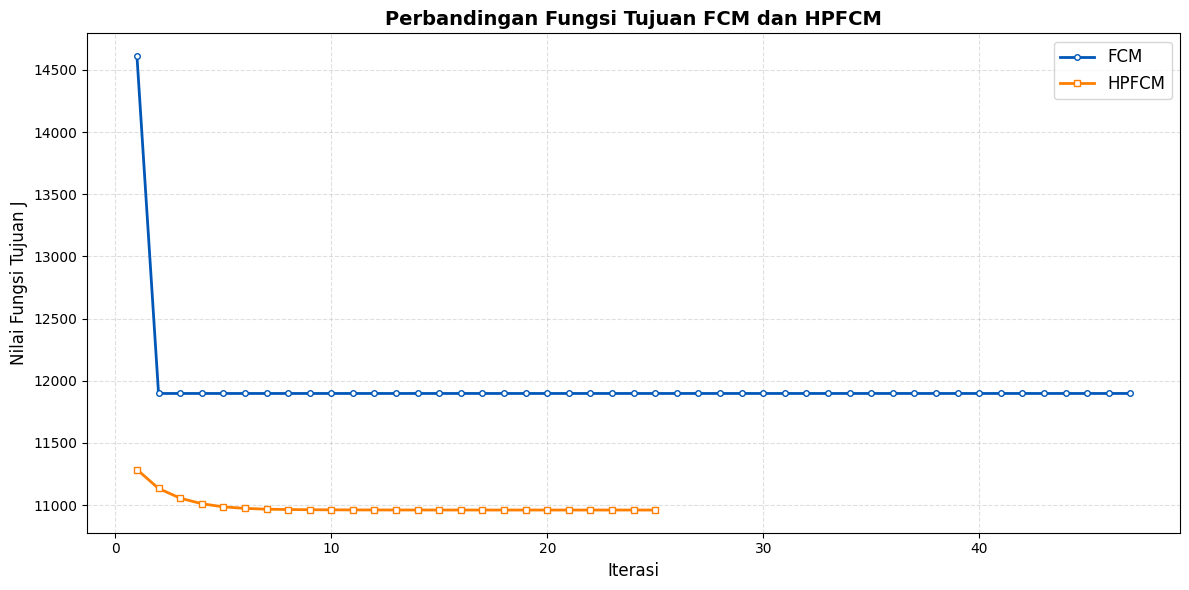

In [ ]:
J_fcm = res_fcm["J_hist"]
J_hpfcm = res_hpfcm["J_hist"]

plt.figure(figsize=(12,6))

plt.plot(
    range(1, len(J_fcm)+1), J_fcm,
    label="FCM",
    color="#0057B7",
    linewidth=2,
    marker="o",
    markersize=4,
    markerfacecolor="white"
)

plt.plot(
    range(1, len(J_hpfcm)+1), J_hpfcm,
    label="HPFCM",
    color="#FF7F00",
    linewidth=2,
    marker="s",
    markersize=4,
    markerfacecolor="white"
)

plt.xlabel("Iterasi", fontsize=12)
plt.ylabel("Nilai Fungsi Tujuan J", fontsize=12)
plt.title("Perbandingan Fungsi Tujuan FCM dan HPFCM", fontsize=14, fontweight="bold")

plt.legend(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
# Alat evaluasi

def xie_beni_index(U, prototypes, df, m=2.0):
    # Jarak data ke semua prototipe
    D = np.column_stack([gower_dist_to_prototype(df, p) for p in prototypes])

    # Numerator: total compactness
    numerator = np.sum((U**m) * (D**2))

    # Denominator: minimum squared distance antar prototipe
    min_proto_dist = float("inf")
    k = len(prototypes)

    for i in range(k):
        for j in range(i+1, k):
            # hitung jarak antara prototipe i dan j
            p1 = prototypes[i]
            p2 = prototypes[j]

            dist = 0
            for c in features:
                if c in numeric_cols:
                    denom = num_max[c] - num_min[c]
                    denom = denom if denom != 0 else 1
                    dist += abs(p1[c] - p2[c]) / denom

                elif c in ordinal_cols:
                    denom = ordinal_max[c] - ordinal_min[c]
                    denom = denom if denom != 0 else 1
                    dist += abs(p1[c] - p2[c]) / denom

                else:  #kategorik
                    dist += float(p1[c] != p2[c])

            dist = dist / len(features)
            min_proto_dist = min(min_proto_dist, dist)

    denominator = len(df) * (min_proto_dist**2 + 1e-12)

    return numerator / denominator

def partition_coefficient(U):
    return np.sum(U**2) / len(U)

def silhouette_gower(df, labels, prototypes):
    n = len(df)
    k = len(prototypes)
    D = np.column_stack([gower_dist_to_prototype(df, p) for p in prototypes])
    s = []
    for i in range(n):
        ci = labels[i]
        ai = D[i, ci]
        bi = min(D[i,j] for j in range(k) if j != ci)
        s.append((bi - ai) / max(ai, bi))
    return np.mean(s)

print("\n=== METRIK FCM ===")
print("Silhouette =", silhouette_gower(X, res_fcm["labels"], res_fcm["prototypes"]))
print("XB =", xie_beni_index(res_fcm["U"], res_fcm["prototypes"], X))
print("PC =", partition_coefficient(res_fcm["U"]))

print("\n=== METRIK HPFCM ===")
print("Silhouette =", silhouette_gower(X, res_hpfcm["labels"], res_hpfcm["prototypes"]))
print("XB =", xie_beni_index(res_hpfcm["U"], res_hpfcm["prototypes"], X))
print("PC =", partition_coefficient(res_hpfcm["U"]))


=== METRIK FCM ===
Silhouette = 0.000508334157317248
XB = 1445911.7406119937
PC = 0.5000001955389249

=== METRIK HPFCM ===
Silhouette = 0.34190863455162174
XB = 0.5760146283461405
PC = 0.6043724885720198


In [ ]:
# === SUMMARY OF CLUSTERS ===
def cluster_summary(df, labels):
    df_temp = df.copy()
    df_temp["cluster"] = labels
    summary = df_temp.groupby("cluster").agg(["mean", "median", "min", "max"])
    return summary

# FCM summary
print("=== RINGKASAN CLUSTER FCM ===")
display(cluster_summary(df[features], res_fcm["labels"]).head(30))

# HPFCM summary
print("=== RINGKASAN CLUSTER HPFCM ===")
display(cluster_summary(df[features], res_hpfcm["labels"]).head(30))

=== RINGKASAN CLUSTER FCM ===


HighBP                 HighChol                CholCheck         \
             mean median min max      mean median min max      mean median   
cluster                                                                      
0        0.386334    0.0   0   1  0.391877    0.0   0   1  0.961434    1.0   
1        0.573829    1.0   0   1  0.533571    1.0   0   1  0.966862    1.0   

         ... Age     Education                   Income                 
         ... min max      mean median min max      mean median min max  
cluster  ...                                                            
0        ...   1  13  5.168031    5.0   1   6  6.466670    7.0   1   8  
1        ...   1  13  4.651261    5.0   1   6  4.652682    5.0   1   8  

[2 rows x 84 columns]

=== RINGKASAN CLUSTER HPFCM ===


HighBP                 HighChol                CholCheck         \
            mean median min max      mean median min max      mean median   
cluster                                                                     
0        0.82903    1.0   0   1  0.797481    1.0   0   1  0.981400    1.0   
1        0.24601    0.0   0   1  0.253329    0.0   0   1  0.954102    1.0   

         ... Age     Education                   Income                 
         ... min max      mean median min max      mean median min max  
cluster  ...                                                            
0        ...   1  13  4.705471    5.0   1   6  5.133368    5.0   1   8  
1        ...   1  13  5.208235    5.0   1   6  6.474957    7.0   1   8  

[2 rows x 84 columns]

In [ ]:
print("Jumlah anggota cluster FCM:")
print(pd.Series(res_fcm["labels"]).value_counts())

print("\nJumlah anggota cluster HPFCM:")
print(pd.Series(res_hpfcm["labels"]).value_counts())

Jumlah anggota cluster FCM:
0    195952
1     57728
Name: count, dtype: int64

Jumlah anggota cluster HPFCM:
1    174058
0     79622
Name: count, dtype: int64


In [ ]:
# from sklearn.manifold import TSNE

# # use one-hot encoding for categorical
# tsne_data = pd.get_dummies(df[features], drop_first=True)

# tsne = TSNE(n_components=2, perplexity=40, learning_rate=200, random_state=42)
# Z = tsne.fit_transform(tsne_data)

# plt.figure(figsize=(14,5))

# # --- FCM ---
# plt.subplot(1,2,1)
# plt.scatter(Z[:,0], Z[:,1], c=res_fcm["labels"], cmap="viridis", s=5, alpha=0.7)
# plt.title("FCM Result (t-SNE)")

# # --- HPFCM ---
# plt.subplot(1,2,2)
# plt.scatter(Z[:,0], Z[:,1], c=res_hpfcm["labels"], cmap="viridis", s=5, alpha=0.7)
# plt.title("HPFCM Result (t-SNE)")

# plt.show()

In [ ]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# # gabungkan data + label cluster
# df_fcm = df.copy()
# df_fcm["Cluster_FCM"] = res_fcm["labels"]

# df_hpfcm = df.copy()
# df_hpfcm["Cluster_HPFCM"] = res_hpfcm["labels"]

# # hitung mean tiap fitur per cluster
# mean_fcm = df_fcm.groupby("Cluster_FCM").mean()
# mean_hpfcm = df_hpfcm.groupby("Cluster_HPFCM").mean()

# # --- Plot heatmap FCM ---
# plt.figure(figsize=(20,6))
# sns.heatmap(mean_fcm, cmap="viridis", annot=False)
# plt.title("Heatmap Mean Setiap Fitur per Cluster (FCM)")
# plt.xlabel("Fitur")
# plt.ylabel("Cluster")
# plt.show()

# # --- Plot heatmap HPFCM ---
# plt.figure(figsize=(20,6))
# sns.heatmap(mean_hpfcm, cmap="viridis", annot=False)
# plt.title("Heatmap Mean Setiap Fitur per Cluster (HPFCM)")
# plt.xlabel("Fitur")
# plt.ylabel("Cluster")
# plt.show()

In [ ]:
# from pandas.plotting import parallel_coordinates

# # siapkan dataframe untuk FCM
# df_vis_fcm = df.copy()
# df_vis_fcm["Cluster"] = res_fcm["labels"].astype(str)

# plt.figure(figsize=(16,6))
# parallel_coordinates(df_vis_fcm, "Cluster", colormap="viridis", alpha=0.05)
# plt.title("Parallel Coordinates Plot - FCM")
# plt.ylabel("Scaled Feature Values (Gower preserves scale automatically)")
# plt.grid(alpha=0.2)
# plt.show()

# # untuk HPFCM
# df_vis_hpfcm = df.copy()
# df_vis_hpfcm["Cluster"] = res_hpfcm["labels"].astype(str)

# plt.figure(figsize=(16,6))
# parallel_coordinates(df_vis_hpfcm, "Cluster", colormap="viridis", alpha=0.05)
# plt.title("Parallel Coordinates Plot - HPFCM")
# plt.grid(alpha=0.2)
# plt.show()

In [ ]:
# import pandas as pd
# pd.set_option("display.max_columns", None)
# pd.set_option("display.max_rows", None)
# # === SUMMARY OF CLUSTERS ===
# def cluster_summary(df, labels):
#     df_temp = df.copy()
#     df_temp["cluster"] = labels
#     summary = df_temp.groupby("cluster").agg(["mean", "median", "min", "max"])
#     return summary

# # FCM summary
# print("=== RINGKASAN CLUSTER FCM ===")
# summary_fcm = cluster_summary(df[features], res_fcm["labels"])
# display(summary_fcm)

# # HPFCM summary
# print("=== RINGKASAN CLUSTER HPFCM ===")
# summary_hpfcm = cluster_summary(df[features], res_hpfcm["labels"])
# display(summary_hpfcm)

In [ ]:
def cluster_summary_complete(df, labels, cat_cols, ordinal_cols, numeric_cols):
    df_temp = df.copy()
    df_temp["cluster"] = labels

    # =====================
    # NUMERICAL
    # =====================
    print("\n===== NUMERICAL =====")
    num_summary = df_temp.groupby("cluster")[numeric_cols].agg(["mean", "median"])
    display(num_summary)

    # =====================
    # ORDINAL
    # =====================
    print("\n===== ORDINAL =====")
    for col in ordinal_cols:
        print(f"\n--- {col} ---")

        # Median
        median = df_temp.groupby("cluster")[col].median()
        print("Median:")
        display(median)

        # Modus
        mode = df_temp.groupby("cluster")[col].agg(lambda x: x.mode().iloc[0])
        print("Mode:")
        display(mode)

        # Proporsi
        count = df_temp.groupby("cluster")[col].value_counts().unstack().fillna(0)
        prop = count.div(count.sum(axis=1), axis=0) * 100

        print("Proportion (%):")
        display(prop.round(2))

    # =====================
    # CATEGORICAL
    # =====================
    print("\n===== CATEGORICAL =====")
    for col in cat_cols:
        print(f"\n--- {col} ---")

        # Count
        count = df_temp.groupby("cluster")[col].value_counts().unstack().fillna(0)
        print("Count:")
        display(count)

        # Proporsi
        prop = count.div(count.sum(axis=1), axis=0) * 100
        print("Proportion (%):")
        display(prop.round(2))

        # Modus
        mode = df_temp.groupby("cluster")[col].agg(lambda x: x.mode().iloc[0])
        print("Mode:")
        display(mode)

In [ ]:
print("=== FCM ===")
cluster_summary_complete(df[features], res_fcm["labels"],
                         cat_cols, ordinal_cols, numeric_cols)

=== FCM ===

===== NUMERICAL =====


BMI       
              mean median
cluster                  
0        27.870887   27.0
1        30.118521   29.0


===== ORDINAL =====

--- GenHlth ---
Median:


,GenHlth
cluster,
0,2.0
1,4.0


Mode:


...

Sex,0,1
cluster,,
0,43577,36045
1,98397,75661


Proportion (%):


Sex,0,1
cluster,,
0,54.73,45.27
1,56.53,43.47


Mode:


,Sex
cluster,
0,0
1,0


In [ ]:
print("=== HPFCM ===")
cluster_summary_complete(df[features], res_hpfcm["labels"],
                         cat_cols, ordinal_cols, numeric_cols)

=== HPFCM ===

===== NUMERICAL =====


BMI       
              mean median
cluster                  
0        30.009369   29.0
1        27.638098   27.0


===== ORDINAL =====

--- GenHlth ---
Median:


,GenHlth
cluster,
0,3.0
1,2.0


Mode:


...

Sex,0,1
cluster,,
0,43577,36045
1,98397,75661


Proportion (%):


Sex,0,1
cluster,,
0,54.73,45.27
1,56.53,43.47


Mode:


,Sex
cluster,
0,0
1,0
